## Bitly data from 1.USA.gov


In [ ]:
import numpy as np
import pandas as pd

path = "datasets/bitly_usagov/example.txt"

# raw data
with open(path) as f:
    print(f.readline())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }



In [3]:
import json

# converting to a dict array
with open(path) as f:
    records = [json.loads(line) for line in f]

records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [4]:
# finding time zones that occur most often:
time_zones = [rec["tz"] for rec in records if "tz" in rec]  # not all records have tz field
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

In [5]:
frame = pd.DataFrame(records)
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

In [ ]:
frame["tz"].head()

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: object

In [ ]:
frame["tz"].value_counts()

tz
America/New_York             1251
                              521
America/Chicago               400
America/Los_Angeles           382
America/Denver                191
                             ... 
America/Argentina/Cordoba       1
Europe/Volgograd                1
America/La_Paz                  1
Africa/Casablanca               1
America/Tegucigalpa             1
Name: count, Length: 97, dtype: int64

In [ ]:
# making it prettier:
clean_tz = frame["tz"].fillna("Missing")
clean_tz[clean_tz == ""] = "Unknown"
tz_counts = clean_tz.value_counts()

tz_counts

tz
America/New_York             1251
Unknown                       521
America/Chicago               400
America/Los_Angeles           382
America/Denver                191
                             ... 
America/Argentina/Cordoba       1
Europe/Volgograd                1
America/La_Paz                  1
Africa/Casablanca               1
America/Tegucigalpa             1
Name: count, Length: 98, dtype: int64

<Axes: ylabel='tz'>

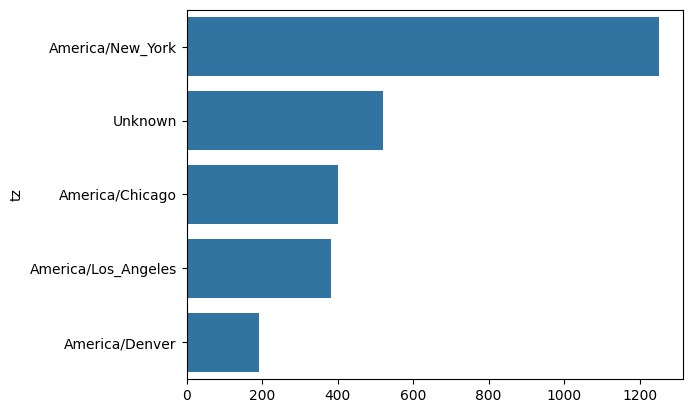

In [ ]:
# horizontal bar plot of top tzs:
import seaborn as sns

subset = tz_counts.head()
sns.barplot(y=subset.index, x=subset.to_numpy())

In [ ]:
# parsing the 'a' field - browser data
frame["a"][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

In [ ]:
# getting the first word - browser capabilities
results = pd.Series([x.split()[0] for x in frame["a"].dropna()])
results.head()

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: object

In [16]:
results.value_counts()

Mozilla/5.0                                          2594
Mozilla/4.0                                           601
GoogleMaps/RochesterNY                                121
Opera/9.80                                             34
TEST_INTERNET_AGENT                                    24
GoogleProducer                                         21
Mozilla/6.0                                             5
BlackBerry8520/5.0.0.681                                4
BlackBerry8520/5.0.0.592                                3
Dalvik/1.4.0                                            3
BlackBerry9630/5.0.0.975                                2
Goldfire                                                2
Acoon                                                   2
Socialite/7766                                          2
Nokia6790s-1b/ATT.03.22                                 1
BlackBerry8520/5.0.0.1067                               1
LG-LG220C[TF268435458416597116000000013524223841]       1
SAMSUNG-SGH-A8

In [ ]:
# split top time zones into Windows and non-Windows users
cframe = frame[frame["a"].notna()].copy()
cframe["os"] = np.where(cframe["a"].str.contains("Windows"), "Windows", "Not Windows")
cframe[["a", "os"]].head()

,a,os
0,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,Windows
1,GoogleMaps/RochesterNY,Not Windows
2,Mozilla/4.0 (compatible; MSIE 8.0; Windows NT ...,Windows
3,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8)...,Not Windows
4,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,Windows


In [21]:
by_tz_os = cframe.groupby(["tz", "os"])
by_tz_os.describe()

nk                                           \
                               count      mean       std  min  25%  50%   75%   
tz                os                                                            
                  Not Windows  245.0  0.281633  0.450716  0.0  0.0  0.0  1.00   
                  Windows      276.0  0.500000  0.500908  0.0  0.0  0.5  1.00   
Africa/Cairo      Windows        3.0  0.333333  0.577350  0.0  0.0  0.0  0.50   
Africa/Casablanca Windows        1.0  0.000000       NaN  0.0  0.0  0.0  0.00   
Africa/Ceuta      Windows        2.0  0.000000  0.000000  0.0  0.0  0.0  0.00   
...                              ...       ...       ...  ...  ...  ...   ...   
Europe/Warsaw     Windows       15.0  0.133333  0.351866  0.0  0.0  0.0  0.00   
Europe/Zurich     Not Windows    4.0  0.250000  0.500000  0.0  0.0  0.0  0.25   
Pacific/Auckland  Not Windows    3.0  1.000000  0.000000  1.0  1.0  1.0  1.00   
                  Windows        8.0  0.000000  0.000000  0.0  0.0  0.0  0.00   
Pacific/Honolulu  Windows       36.0  0.833333  0.377964  0.0  1.0  1.0  1.00   

                                        t                ...            hc  \
                               max  count          mean  ...           75%   
tz                os                                     ...                 
                  Not Windows  1.0  245.0  1.331925e+09  ...  1.331916e+09   
                  Windows      1.0  276.0  1.331925e+09  ...  1.331922e+09   
Africa/Cairo      Windows      1.0    3.0  1.331924e+09  ...  1.331923e+09   
Africa/Casablanca Windows      0.0    1.0  1.331926e+09  ...  1.328021e+09   
Africa/Ceuta      Windows      0.0    2.0  1.331925e+09  ...  1.331649e+09   
...                            ...    ...           ...  ...           ...   
Europe/Warsaw     Windows      1.0   15.0  1.331924e+09  ...  1.331923e+09   
Europe/Zurich     Not Windows  1.0    4.0  1.331925e+09  ...  1.331918e+09   
Pacific/Auckland  Not Windows  1.0    3.0  1.331926e+09  ...  1.331872e+09   
                  Windows      0.0    8.0  1.331926e+09  ...  1.331908e+09   
Pacific/Honolulu  Windows      1.0   36.0  1.331924e+09  ...  1.331923e+09   

                                            _heartbeat_                       \
                                        max       count mean std min 25% 50%   
tz                os                                                           
                  Not Windows  1.331925e+09         0.0  NaN NaN NaN NaN NaN   
                  Windows      1.331926e+09         0.0  NaN NaN NaN NaN NaN   
Africa/Cairo      Windows      1.331923e+09         0.0  NaN NaN NaN NaN NaN   
Africa/Casablanca Windows      1.328021e+09         0.0  NaN NaN NaN NaN NaN   
Africa/Ceuta      Windows      1.331671e+09         0.0  NaN NaN NaN NaN NaN   
...                                     ...         ...  ...  ..  ..  ..  ..   
Europe/Warsaw     Windows      1.331923e+09         0.0  NaN NaN NaN NaN NaN   
Europe/Zurich     Not Windows  1.331923e+09         0.0  NaN NaN NaN NaN NaN   
Pacific/Auckland  Not Windows  1.331908e+09         0.0  NaN NaN NaN NaN NaN   
                  Windows      1.331923e+09         0.0  NaN NaN NaN NaN NaN   
Pacific/Honolulu  Windows      1.331923e+09         0.0  NaN NaN NaN NaN NaN   

                                       
                              75% max  
tz                os                   
                  Not Windows NaN NaN  
                  Windows     NaN NaN  
Africa/Cairo      Windows     NaN NaN  
Africa/Casablanca Windows     NaN NaN  
Africa/Ceuta      Windows     NaN NaN  
...                            ..  ..  
Europe/Warsaw     Windows     NaN NaN  
Europe/Zurich     Not Windows NaN NaN  
Pacific/Auckland  Not Windows NaN NaN  
                  Windows     NaN NaN  
Pacific/Honolulu  Windows     NaN NaN  

[149 rows x 32 columns]

In [34]:
agg_counts = by_tz_os.size()
agg_counts

tz                 os         
                   Not Windows    245
                   Windows        276
Africa/Cairo       Windows          3
Africa/Casablanca  Windows          1
Africa/Ceuta       Windows          2
                                 ... 
Europe/Warsaw      Windows         15
Europe/Zurich      Not Windows      4
Pacific/Auckland   Not Windows      3
                   Windows          8
Pacific/Honolulu   Windows         36
Length: 149, dtype: int64

In [35]:
# making it a df:
agg_counts = agg_counts.unstack().fillna(0)
agg_counts

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0
...,...,...
Europe/Volgograd,0.0,1.0
Europe/Warsaw,1.0,15.0
Europe/Zurich,4.0,0.0


In [ ]:
# select top overall timezones:
indexer = agg_counts.sum("columns").argsort()
indexer.values[:10]  # array of indexes of the total users, ordered from smallest to biggest

array([ 2,  7,  5,  4, 14, 11,  9,  8, 24, 26])

In [41]:
# take the rows based on their indexes, using the last 10 indexes from the array we just created
count_subset = agg_counts.take(indexer[-10:])
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


In [ ]:
# using nlargest():
agg_counts.sum("columns").nlargest(10)

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

In [ ]:
# plotting with seaborn
# making it into a series with two index levels:
count_subset = count_subset.stack()
count_subset

tz                   os         
America/Sao_Paulo    Not Windows     13.0
                     Windows         20.0
Europe/Madrid        Not Windows     16.0
                     Windows         19.0
Pacific/Honolulu     Not Windows      0.0
                     Windows         36.0
Asia/Tokyo           Not Windows      2.0
                     Windows         35.0
Europe/London        Not Windows     43.0
                     Windows         31.0
America/Denver       Not Windows    132.0
                     Windows         59.0
America/Los_Angeles  Not Windows    130.0
                     Windows        252.0
America/Chicago      Not Windows    115.0
                     Windows        285.0
                     Not Windows    245.0
                     Windows        276.0
America/New_York     Not Windows    339.0
                     Windows        912.0
dtype: float64

In [ ]:
# giving the series a name:
count_subset.name = "total"
count_subset

tz                   os         
America/Sao_Paulo    Not Windows     13.0
                     Windows         20.0
Europe/Madrid        Not Windows     16.0
                     Windows         19.0
Pacific/Honolulu     Not Windows      0.0
                     Windows         36.0
Asia/Tokyo           Not Windows      2.0
                     Windows         35.0
Europe/London        Not Windows     43.0
                     Windows         31.0
America/Denver       Not Windows    132.0
                     Windows         59.0
America/Los_Angeles  Not Windows    130.0
                     Windows        252.0
America/Chicago      Not Windows    115.0
                     Windows        285.0
                     Not Windows    245.0
                     Windows        276.0
America/New_York     Not Windows    339.0
                     Windows        912.0
Name: total, dtype: float64

In [44]:
# turning current indexes into columns. the name we just applied will be assigned to the series data column
count_subset = count_subset.reset_index()
count_subset

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


<Axes: xlabel='total', ylabel='tz'>

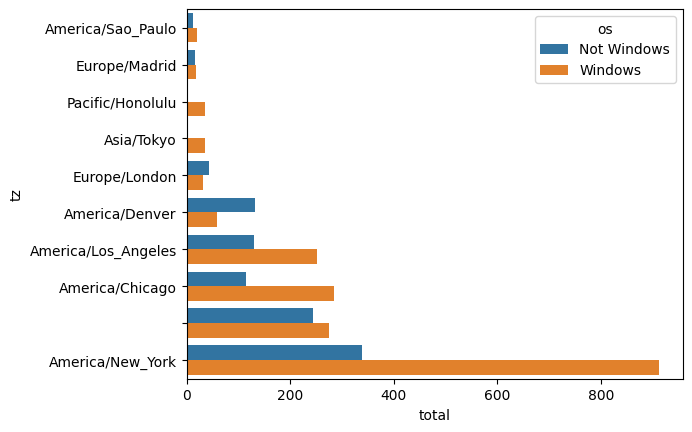

In [ ]:
sns.barplot(x="total", y="tz", hue="os", data=count_subset)

In [ ]:
# normalizing to better visualize the relative percentage of Windows users in smaller groups:
# def norm_total(group):
#     group['normed_total'] = group["total"] / group["total"].sum()
#     return group

# results = count_subset.groupby('tz').apply(norm_total)

# more efficient way:
g = count_subset.groupby("tz")
results = count_subset["total"] / g["total"].transform("sum")
results

0     0.393939
1     0.606061
2     0.457143
3     0.542857
4     0.000000
5     1.000000
6     0.054054
7     0.945946
8     0.581081
9     0.418919
10    0.691099
11    0.308901
12    0.340314
13    0.659686
14    0.287500
15    0.712500
16    0.470250
17    0.529750
18    0.270983
19    0.729017
Name: total, dtype: float64

<Axes: xlabel='normed_total', ylabel='tz'>

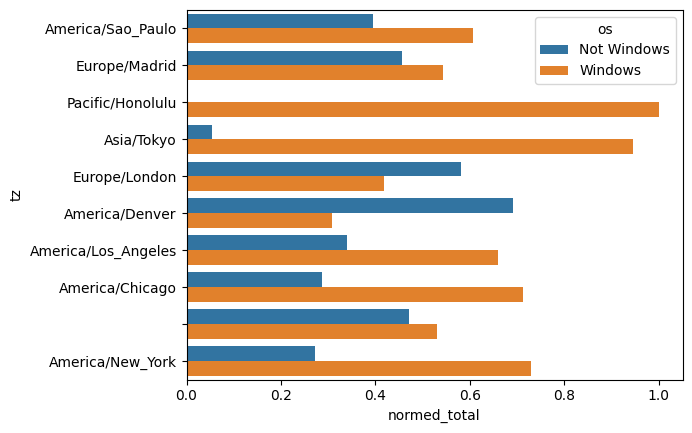

In [ ]:
count_subset["normed_total"] = results
sns.barplot(x="normed_total", y="tz", hue="os", data=count_subset)